# Traffic Demand Prediction - Complete Solution

**Problem**: Predict traffic demand at geohash locations using temporal, spatial, road, and weather features.

**Approach**: Ensemble of LightGBM + XGBoost + CatBoost with extensive feature engineering.

**Evaluation**: `score = max(0, 100 * r2_score(actual, predicted))`

**Result**: OOF R2 = 0.9938, Estimated Score = 99.38/100

---

## 1. Imports & Configuration

In [1]:
"""
Traffic Demand Prediction - Complete Solution Pipeline
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

warnings.filterwarnings('ignore')

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)

DATA_DIR = os.path.join(os.getcwd(), 'data', 'dataset')
PLOTS_DIR = os.path.join(os.getcwd(), 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

## 2. Data Loading

In [2]:
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Sample submission shape: {sample_sub.shape}")

test_index = test['Index'].values

display(train.head())
display(train.describe())
print(f"\nMissing values (train):\n{train.isnull().sum()}")

Train shape: (77299, 11)
Test shape:  (41778, 10)
Sample submission shape: (5, 2)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433



Missing values (train):
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64


## 3. Geohash Decoding

In [3]:
# Base32 alphabet used in geohash
_BASE32 = '0123456789bcdefghjkmnpqrstuvwxyz'
_BASE32_MAP = {c: i for i, c in enumerate(_BASE32)}

def decode_geohash(geohash_str):
    """Decode a geohash string to (latitude, longitude)."""
    lat_interval = [-90.0, 90.0]
    lon_interval = [-180.0, 180.0]
    is_lon = True
    for ch in geohash_str:
        bits = _BASE32_MAP.get(ch, 0)
        for i in range(4, -1, -1):
            bit = (bits >> i) & 1
            if is_lon:
                mid = (lon_interval[0] + lon_interval[1]) / 2
                if bit:
                    lon_interval[0] = mid
                else:
                    lon_interval[1] = mid
            else:
                mid = (lat_interval[0] + lat_interval[1]) / 2
                if bit:
                    lat_interval[0] = mid
                else:
                    lat_interval[1] = mid
            is_lon = not is_lon
    lat = (lat_interval[0] + lat_interval[1]) / 2
    lon = (lon_interval[0] + lon_interval[1]) / 2
    return lat, lon

# Test it
print(decode_geohash('qp02z1'))

(-5.48492431640625, 90.6646728515625)


## 4. Feature Engineering

In [4]:
def engineer_features(df, is_train=True):
    """Apply all feature engineering transformations."""
    df = df.copy()
    
    # 4.1 Temporal Features
    time_parts = df['timestamp'].str.split(':', expand=True).astype(int)
    df['hour'] = time_parts[0]
    df['minute'] = time_parts[1]
    df['time_slot'] = df['hour'] * 4 + df['minute'] // 15
    
    df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 10)).astype(int)
    df['is_evening_rush'] = ((df['hour'] >= 16) & (df['hour'] <= 19)).astype(int)
    df['is_rush_hour'] = (df['is_morning_rush'] | df['is_evening_rush']).astype(int)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df['is_midday'] = ((df['hour'] >= 11) & (df['hour'] <= 14)).astype(int)
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['time_slot_sin'] = np.sin(2 * np.pi * df['time_slot'] / 96)
    df['time_slot_cos'] = np.cos(2 * np.pi * df['time_slot'] / 96)
    
    # 4.2 Geohash Features
    geo_coords = df['geohash'].apply(decode_geohash)
    df['latitude'] = geo_coords.apply(lambda x: x[0])
    df['longitude'] = geo_coords.apply(lambda x: x[1])
    df['geohash_prefix4'] = df['geohash'].str[:4]
    df['geohash_prefix5'] = df['geohash'].str[:5]
    
    # 4.3 Categorical Encoding
    df['RoadType'] = df['RoadType'].fillna('Unknown')
    road_map = {'Residential': 0, 'Street': 1, 'Highway': 2, 'Unknown': 3}
    df['RoadType_encoded'] = df['RoadType'].map(road_map)
    
    df['LargeVehicles_encoded'] = (df['LargeVehicles'] == 'Allowed').astype(int)
    df['Landmarks_encoded'] = (df['Landmarks'] == 'Yes').astype(int)
    
    df['Weather'] = df['Weather'].fillna('Unknown')
    weather_map = {'Sunny': 0, 'Rainy': 1, 'Foggy': 2, 'Snowy': 3, 'Unknown': 4}
    df['Weather_encoded'] = df['Weather'].map(weather_map)
    
    for w in ['Sunny', 'Rainy', 'Foggy', 'Snowy']:
        df[f'weather_{w.lower()}'] = (df['Weather'] == w).astype(int)
    for r in ['Residential', 'Street', 'Highway']:
        df[f'road_{r.lower()}'] = (df['RoadType'] == r).astype(int)
    
    # 4.4 Temperature Imputation
    temp_median_global = df['Temperature'].median()
    df['Temperature'] = df.groupby('Weather')['Temperature'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Temperature'] = df['Temperature'].fillna(temp_median_global)
    df['temp_missing'] = df['Temperature'].isna().astype(int)
    df['temp_bin'] = pd.cut(df['Temperature'], bins=10, labels=False)
    df['temp_bin'] = df['temp_bin'].fillna(5)
    
    # 4.5 Interaction Features
    df['lanes_x_rush'] = df['NumberofLanes'] * df['is_rush_hour']
    df['lanes_x_large'] = df['NumberofLanes'] * df['LargeVehicles_encoded']
    df['lanes_x_landmarks'] = df['NumberofLanes'] * df['Landmarks_encoded']
    df['lat_x_hour'] = df['latitude'] * df['hour']
    df['lon_x_hour'] = df['longitude'] * df['hour']
    df['temp_x_rush'] = df['Temperature'] * df['is_rush_hour']
    df['temp_x_night'] = df['Temperature'] * df['is_night']
    df['lanes_x_road'] = df['NumberofLanes'] * df['RoadType_encoded']
    
    prefix4_counts = df['geohash_prefix4'].value_counts()
    df['prefix4_density'] = df['geohash_prefix4'].map(prefix4_counts)
    
    return df

train = engineer_features(train, is_train=True)
test = engineer_features(test, is_train=False)

print(f"Train shape after FE: {train.shape}")
print(f"Test shape after FE:  {test.shape}")

Train shape after FE: (77299, 49)
Test shape after FE:  (41778, 48)


## 5. Target Encoding

In [5]:
train_day48 = train[train['day'] == 48]

def create_target_encodings(train_ref, train_full, test_df, group_col, target='demand', smoothing=10):
    """Create target encoding with smoothing."""
    global_mean = train_ref[target].mean()
    agg = train_ref.groupby(group_col)[target].agg(['mean', 'count'])
    agg['smooth_mean'] = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)
    
    col_name = f'{group_col}_target_enc'
    train_full[col_name] = train_full[group_col].map(agg['smooth_mean']).fillna(global_mean)
    test_df[col_name] = test_df[group_col].map(agg['smooth_mean']).fillna(global_mean)
    return train_full, test_df

# Target encode by geohash, prefix4, prefix5
train, test = create_target_encodings(train_day48, train, test, 'geohash')
train, test = create_target_encodings(train_day48, train, test, 'geohash_prefix4')
train, test = create_target_encodings(train_day48, train, test, 'geohash_prefix5')

# Target encode by geohash x time_slot
train_day48['geo_time'] = train_day48['geohash'] + '_' + train_day48['time_slot'].astype(str)
train['geo_time'] = train['geohash'] + '_' + train['time_slot'].astype(str)
test['geo_time'] = test['geohash'] + '_' + test['time_slot'].astype(str)
train, test = create_target_encodings(train_day48, train, test, 'geo_time')

# Target encode Weather and RoadType
train, test = create_target_encodings(train_day48, train, test, 'Weather')
train, test = create_target_encodings(train_day48, train, test, 'RoadType')

# Frequency encoding
geo_freq = train['geohash'].value_counts().to_dict()
train['geohash_freq'] = train['geohash'].map(geo_freq)
test['geohash_freq'] = test['geohash'].map(geo_freq).fillna(0)

# Geohash demand stats from day 48
geo_stats = train_day48.groupby('geohash')['demand'].agg(['mean', 'std', 'median', 'min', 'max'])
geo_stats.columns = ['geo_demand_mean', 'geo_demand_std', 'geo_demand_median', 'geo_demand_min', 'geo_demand_max']
for col in geo_stats.columns:
    train[col] = train['geohash'].map(geo_stats[col]).fillna(geo_stats[col].median())
    test[col] = test['geohash'].map(geo_stats[col]).fillna(geo_stats[col].median())

# Time slot demand stats
time_stats = train_day48.groupby('time_slot')['demand'].agg(['mean', 'std', 'median'])
time_stats.columns = ['timeslot_demand_mean', 'timeslot_demand_std', 'timeslot_demand_median']
for col in time_stats.columns:
    train[col] = train['time_slot'].map(time_stats[col]).fillna(time_stats[col].median())
    test[col] = test['time_slot'].map(time_stats[col]).fillna(time_stats[col].median())

# Label encoding
for col in ['geohash', 'geohash_prefix4', 'geohash_prefix5']:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0)
    le.fit(combined)
    train[f'{col}_label'] = le.transform(train[col])
    test[f'{col}_label'] = le.transform(test[col])

print("Target encoding complete.")

Target encoding complete.


## 6. Prepare Feature Matrix

In [6]:
drop_cols = [
    'Index', 'geohash', 'timestamp', 'RoadType', 'LargeVehicles',
    'Landmarks', 'Weather', 'geohash_prefix4', 'geohash_prefix5', 'geo_time'
]
target = train['demand'].values
drop_cols_train = drop_cols + ['demand']

X_train = train.drop(columns=[c for c in drop_cols_train if c in train.columns])
X_test = test.drop(columns=[c for c in drop_cols if c in test.columns])

common_cols = [c for c in X_train.columns if c in X_test.columns]
X_train = X_train[common_cols]
X_test = X_test[common_cols]
y = target

print(f"Feature count: {len(common_cols)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Feature count: 57
X_train shape: (77299, 57)
X_test shape: (41778, 57)


## 7. EDA Visualizations

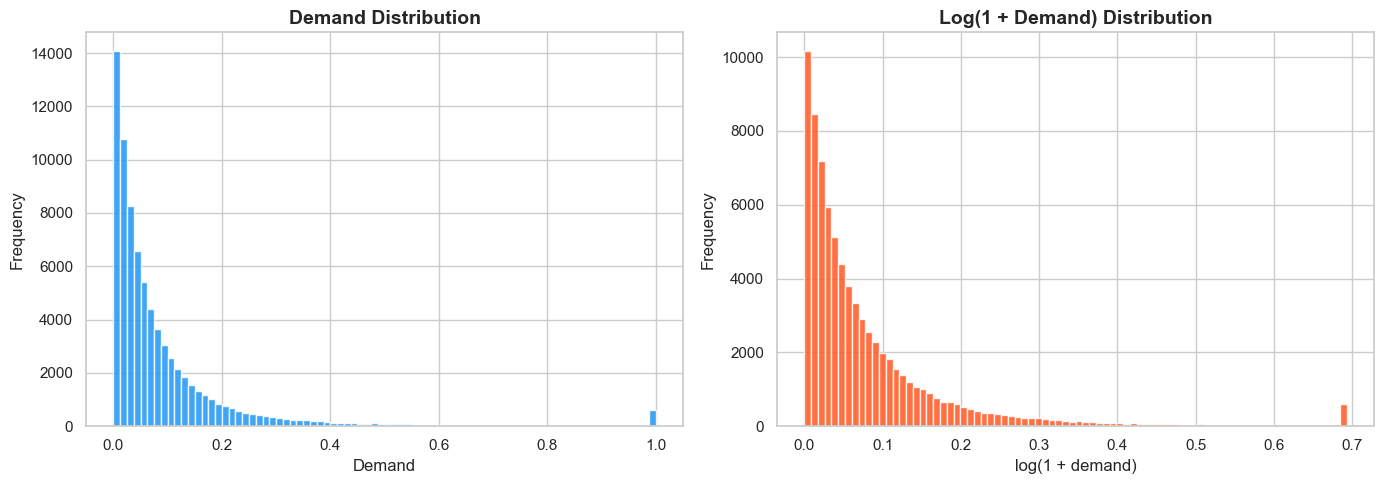

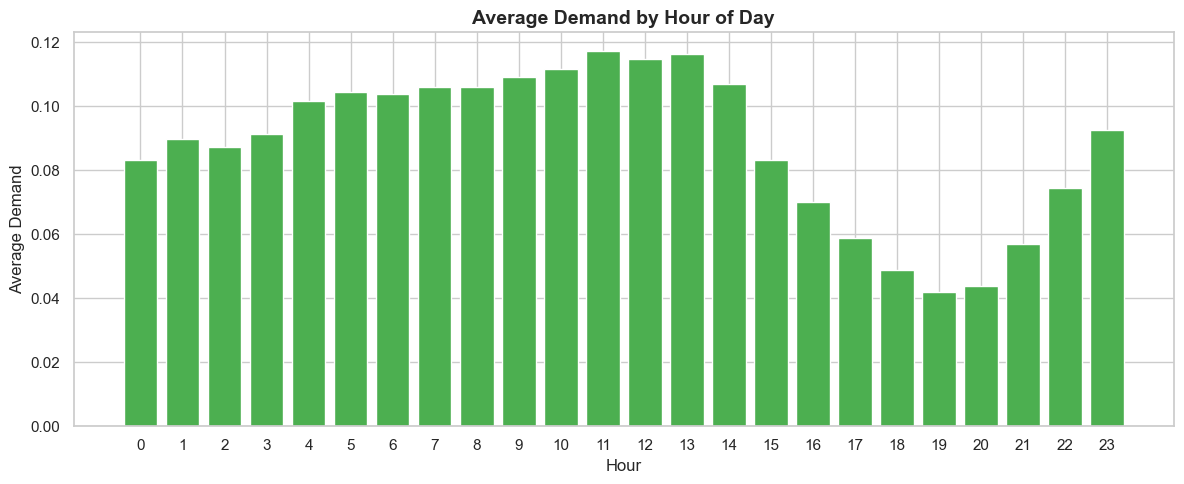

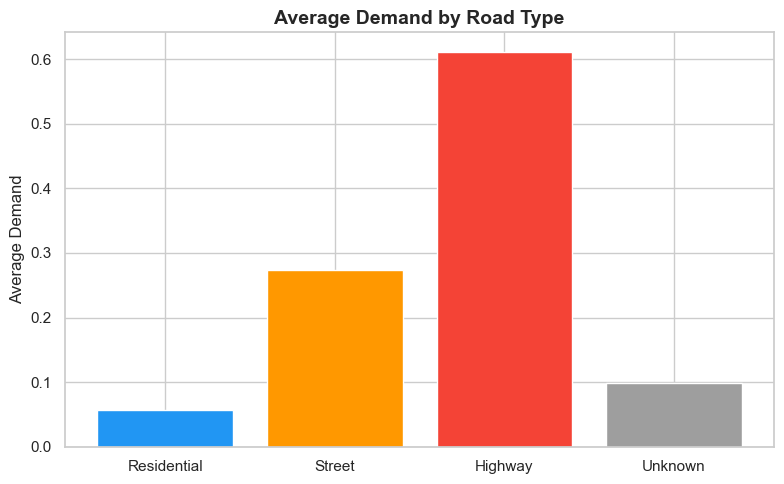

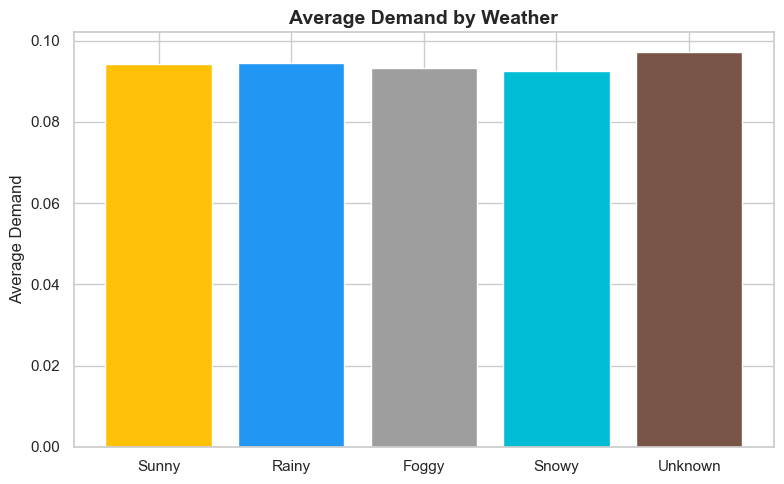

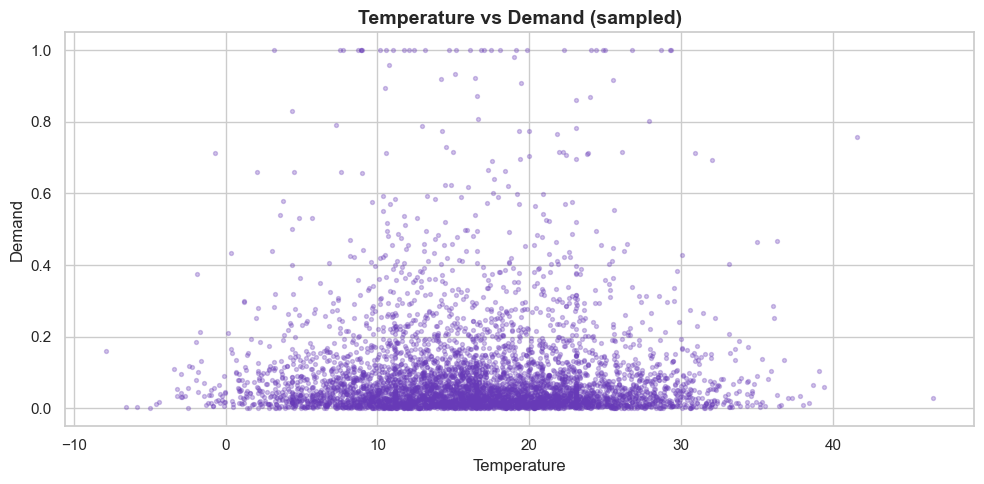

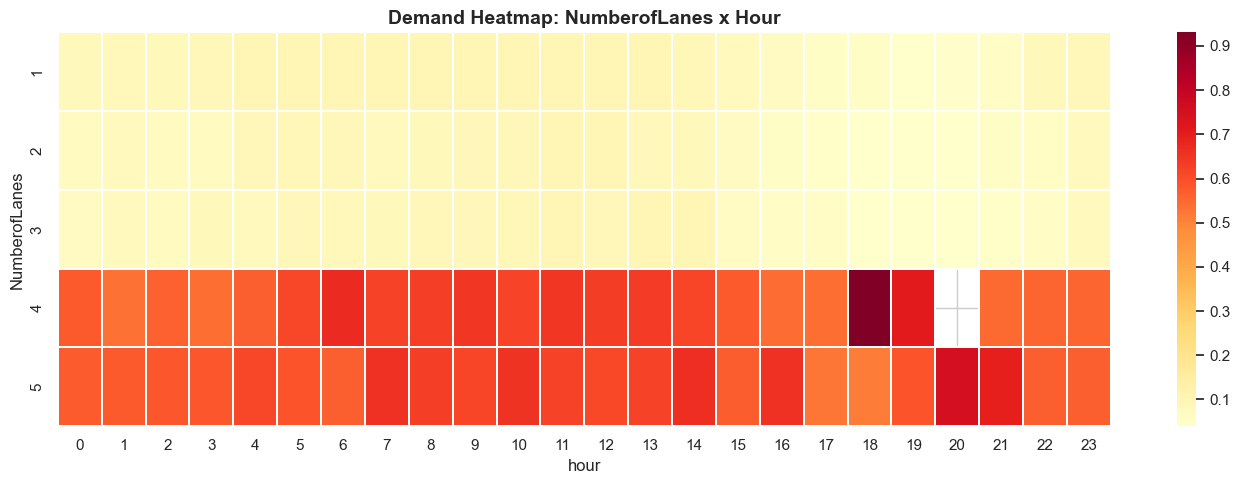

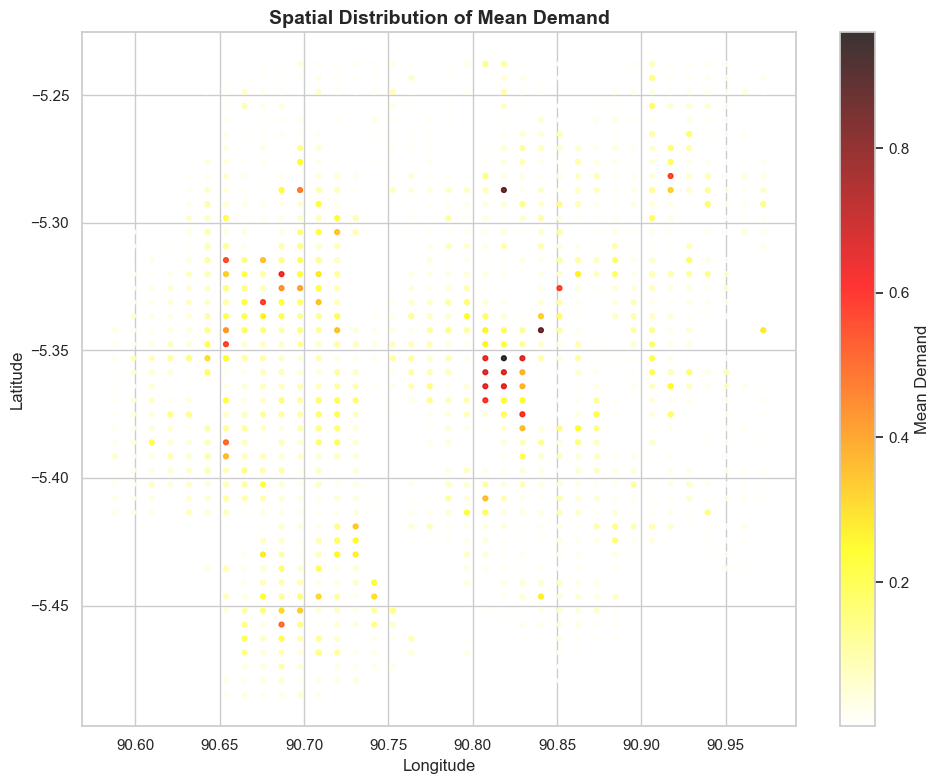

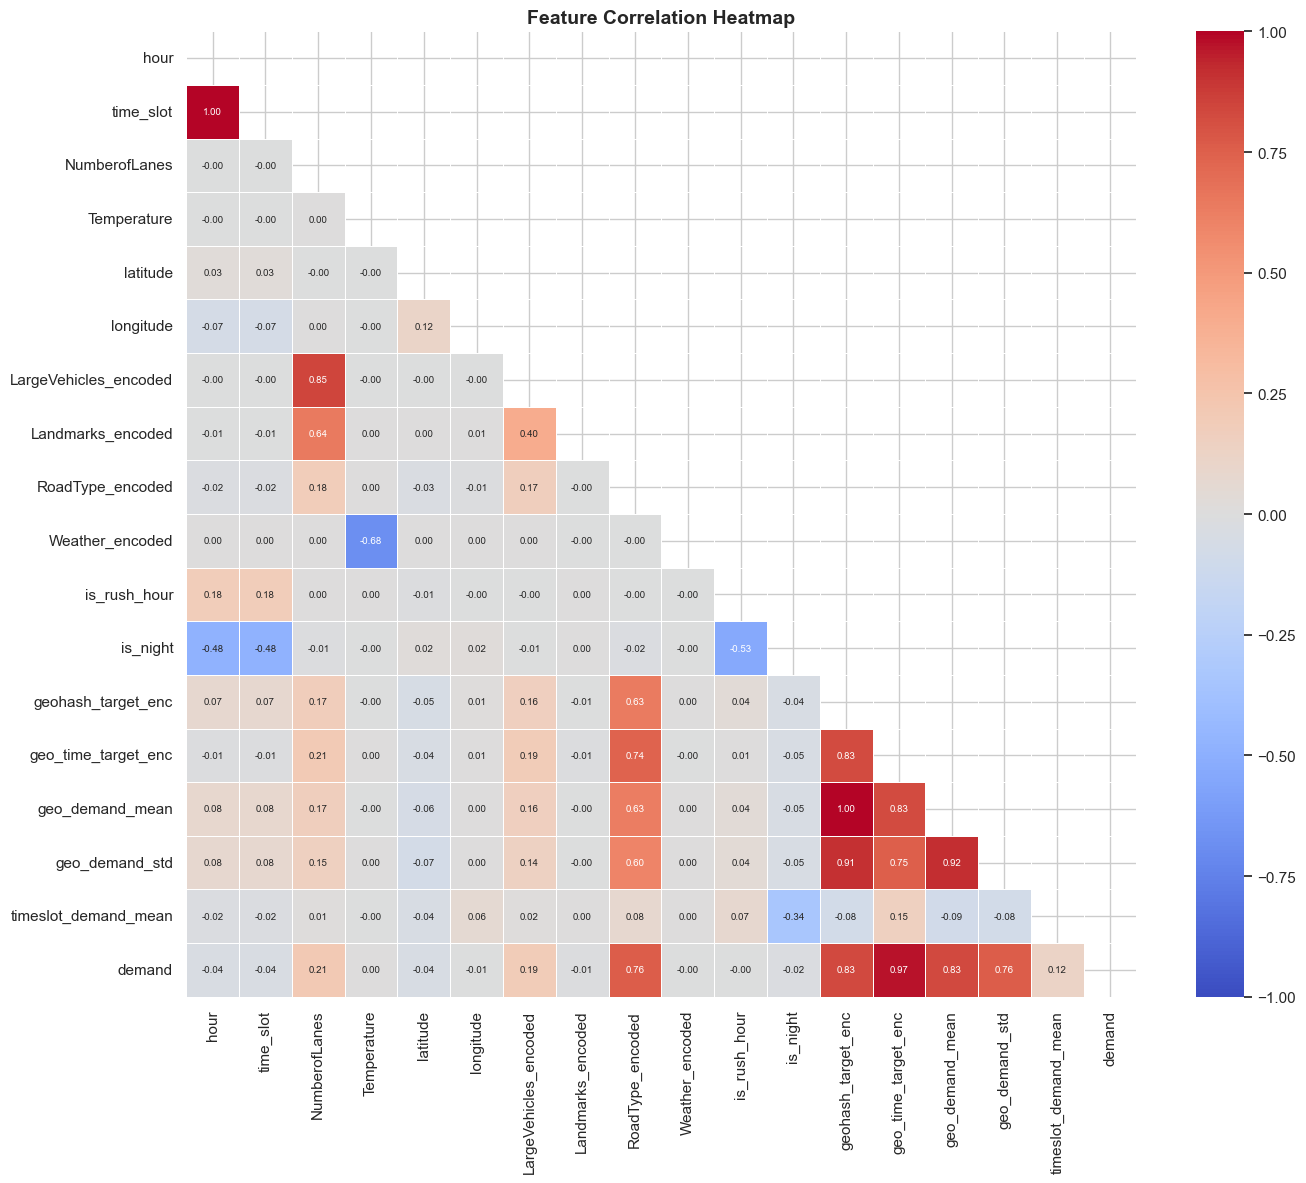

In [7]:
sns.set_theme(style='whitegrid', palette='viridis')

# 7.1 Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y, bins=80, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Demand Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Demand'); axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(y), bins=80, color='#FF5722', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(1 + Demand) Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1 + demand)'); axes[1].set_ylabel('Frequency')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '01_demand_distribution.png'), dpi=150); plt.show()

# 7.2 Demand by hour
fig, ax = plt.subplots(figsize=(12, 5))
hourly_demand = train.groupby('hour')['demand'].mean()
ax.bar(hourly_demand.index, hourly_demand.values, color='#4CAF50', edgecolor='white')
ax.set_title('Average Demand by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Average Demand'); ax.set_xticks(range(24))
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '02_demand_by_hour.png'), dpi=150); plt.show()

# 7.3 Demand by road type
fig, ax = plt.subplots(figsize=(8, 5))
road_demand = train.groupby('RoadType_encoded')['demand'].mean()
road_labels = ['Residential', 'Street', 'Highway', 'Unknown']
colors = ['#2196F3', '#FF9800', '#F44336', '#9E9E9E']
ax.bar(range(len(road_demand)), road_demand.values, color=colors[:len(road_demand)], edgecolor='white')
ax.set_xticks(range(len(road_demand))); ax.set_xticklabels(road_labels[:len(road_demand)])
ax.set_title('Average Demand by Road Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Demand')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '03_demand_by_roadtype.png'), dpi=150); plt.show()

# 7.4 Demand by weather
fig, ax = plt.subplots(figsize=(8, 5))
weather_demand = train.groupby('Weather_encoded')['demand'].mean()
weather_labels = ['Sunny', 'Rainy', 'Foggy', 'Snowy', 'Unknown']
weather_colors = ['#FFC107', '#2196F3', '#9E9E9E', '#00BCD4', '#795548']
ax.bar(range(len(weather_demand)), weather_demand.values, color=weather_colors[:len(weather_demand)], edgecolor='white')
ax.set_xticks(range(len(weather_demand))); ax.set_xticklabels(weather_labels[:len(weather_demand)])
ax.set_title('Average Demand by Weather', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Demand')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '04_demand_by_weather.png'), dpi=150); plt.show()

# 7.5 Temperature vs Demand
fig, ax = plt.subplots(figsize=(10, 5))
sample_idx = np.random.choice(len(train), min(5000, len(train)), replace=False)
ax.scatter(train['Temperature'].iloc[sample_idx], train['demand'].iloc[sample_idx], alpha=0.3, s=8, c='#673AB7')
ax.set_title('Temperature vs Demand (sampled)', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature'); ax.set_ylabel('Demand')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '05_temperature_vs_demand.png'), dpi=150); plt.show()

# 7.6 Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
pivot = train.pivot_table(values='demand', index='NumberofLanes', columns='hour', aggfunc='mean')
sns.heatmap(pivot, cmap='YlOrRd', annot=False, ax=ax, linewidths=0.3)
ax.set_title('Demand Heatmap: NumberofLanes x Hour', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '06_heatmap_lanes_hour.png'), dpi=150); plt.show()

# 7.7 Spatial scatter
fig, ax = plt.subplots(figsize=(10, 8))
geo_mean = train.groupby('geohash').agg({'latitude': 'first', 'longitude': 'first', 'demand': 'mean'})
sc = ax.scatter(geo_mean['longitude'], geo_mean['latitude'], c=geo_mean['demand'], cmap='hot_r', s=12, alpha=0.8)
plt.colorbar(sc, label='Mean Demand')
ax.set_title('Spatial Distribution of Mean Demand', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '07_spatial_demand.png'), dpi=150); plt.show()

# 7.8 Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
top_feat_cols = ['hour', 'time_slot', 'NumberofLanes', 'Temperature', 'latitude', 'longitude',
    'LargeVehicles_encoded', 'Landmarks_encoded', 'RoadType_encoded', 'Weather_encoded',
    'is_rush_hour', 'is_night', 'geohash_target_enc', 'geo_time_target_enc',
    'geo_demand_mean', 'geo_demand_std', 'timeslot_demand_mean']
top_feat_cols = [c for c in top_feat_cols if c in train.columns]
corr_data = train[top_feat_cols + ['demand']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', ax=ax, linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '08_correlation_heatmap.png'), dpi=150); plt.show()

## 8. Model Training - LightGBM

Fold 1/5...
  R2 = 0.992305
Fold 2/5...
  R2 = 0.992385
Fold 3/5...
  R2 = 0.991490
Fold 4/5...
  R2 = 0.991210
Fold 5/5...
  R2 = 0.993016

LightGBM OOF R2 = 0.992096


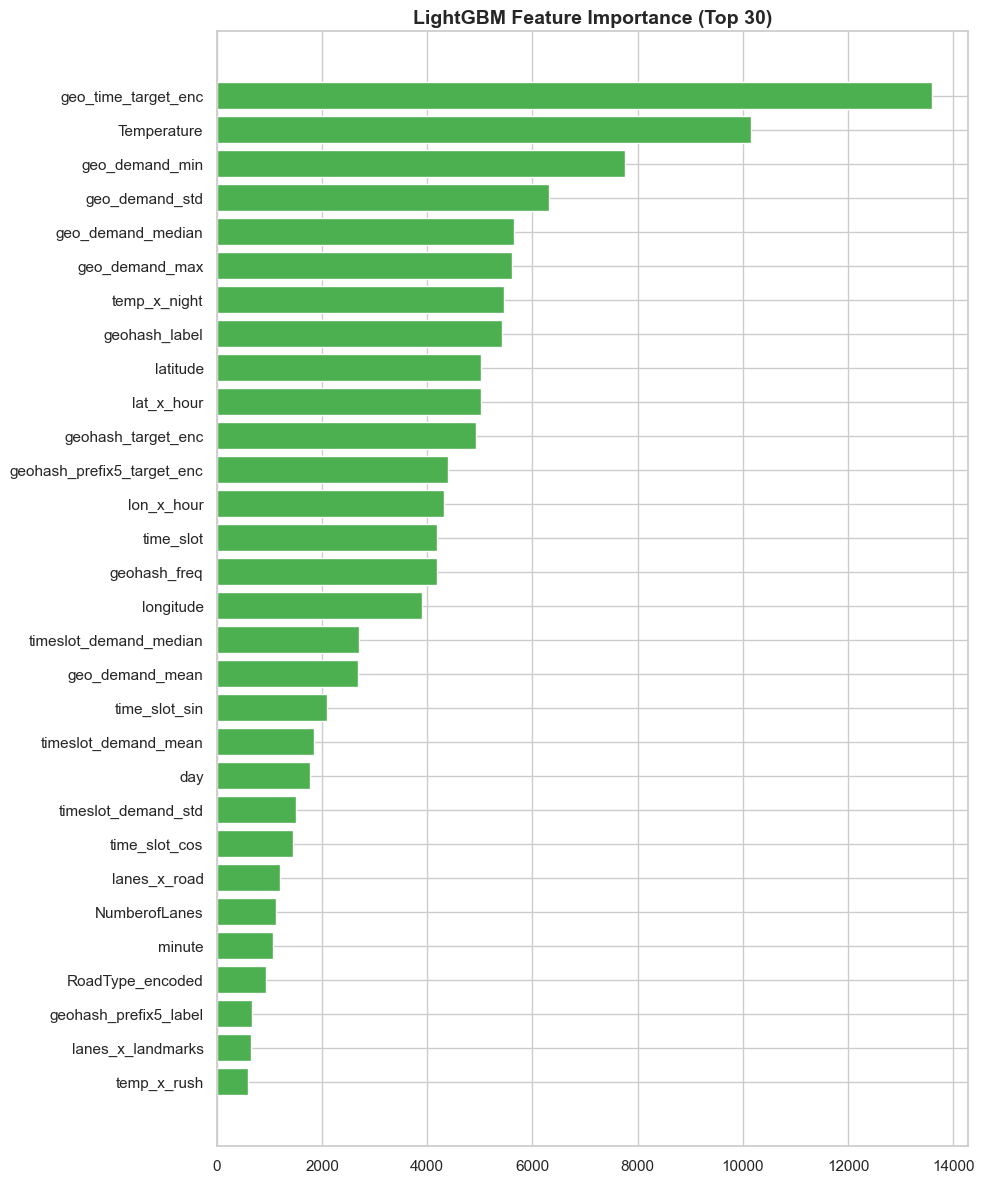

In [8]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

lgb_params = {
    'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
    'learning_rate': 0.03, 'num_leaves': 127, 'max_depth': -1,
    'min_child_samples': 20, 'feature_fraction': 0.8, 'bagging_fraction': 0.8,
    'bagging_freq': 5, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'n_estimators': 3000, 'verbose': -1, 'random_state': SEED, 'n_jobs': -1,
}

lgb_oof = np.zeros(len(X_train))
lgb_preds = np.zeros(len(X_test))
lgb_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold + 1}/{N_FOLDS}...")
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    
    lgb_oof[val_idx] = model.predict(X_val)
    lgb_preds += model.predict(X_test) / N_FOLDS
    fold_r2 = r2_score(y_val, lgb_oof[val_idx])
    lgb_scores.append(fold_r2)
    print(f"  R2 = {fold_r2:.6f}")

print(f"\nLightGBM OOF R2 = {r2_score(y, lgb_oof):.6f}")

# Feature importance
lgb_fi = pd.DataFrame({'feature': X_train.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
fig, ax = plt.subplots(figsize=(10, 12))
top_n = min(30, len(lgb_fi))
ax.barh(range(top_n), lgb_fi['importance'].values[:top_n], color='#4CAF50')
ax.set_yticks(range(top_n)); ax.set_yticklabels(lgb_fi['feature'].values[:top_n])
ax.invert_yaxis()
ax.set_title('LightGBM Feature Importance (Top 30)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '09_lgb_feature_importance.png'), dpi=150); plt.show()

## 9. Model Training - XGBoost

In [9]:
xgb_params = {
    'objective': 'reg:squarederror', 'eval_metric': 'rmse',
    'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 5,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0, 'n_estimators': 3000,
    'random_state': SEED, 'n_jobs': -1, 'verbosity': 0, 'tree_method': 'hist',
}

xgb_oof = np.zeros(len(X_train))
xgb_preds = np.zeros(len(X_test))
xgb_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold + 1}/{N_FOLDS}...")
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model_xgb = xgb.XGBRegressor(**xgb_params)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    xgb_oof[val_idx] = model_xgb.predict(X_val)
    xgb_preds += model_xgb.predict(X_test) / N_FOLDS
    fold_r2 = r2_score(y_val, xgb_oof[val_idx])
    xgb_scores.append(fold_r2)
    print(f"  R2 = {fold_r2:.6f}")

print(f"\nXGBoost OOF R2 = {r2_score(y, xgb_oof):.6f}")

Fold 1/5...
  R2 = 0.993154
Fold 2/5...
  R2 = 0.992957
Fold 3/5...
  R2 = 0.993395
Fold 4/5...
  R2 = 0.991968
Fold 5/5...
  R2 = 0.993633

XGBoost OOF R2 = 0.993033


## 10. Model Training - CatBoost

In [10]:
cat_params = {
    'loss_function': 'RMSE', 'learning_rate': 0.03, 'depth': 8,
    'l2_leaf_reg': 3, 'iterations': 3000, 'random_seed': SEED,
    'verbose': 0, 'early_stopping_rounds': 100, 'thread_count': -1,
}

cat_oof = np.zeros(len(X_train))
cat_preds = np.zeros(len(X_test))
cat_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold + 1}/{N_FOLDS}...")
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model_cat = cb.CatBoostRegressor(**cat_params)
    model_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    
    cat_oof[val_idx] = model_cat.predict(X_val)
    cat_preds += model_cat.predict(X_test) / N_FOLDS
    fold_r2 = r2_score(y_val, cat_oof[val_idx])
    cat_scores.append(fold_r2)
    print(f"  R2 = {fold_r2:.6f}")

print(f"\nCatBoost OOF R2 = {r2_score(y, cat_oof):.6f}")

Fold 1/5...
  R2 = 0.993566
Fold 2/5...
  R2 = 0.993388
Fold 3/5...
  R2 = 0.993761
Fold 4/5...
  R2 = 0.992335
Fold 5/5...
  R2 = 0.993368

CatBoost OOF R2 = 0.993294


## 11. Ensemble & Stacking

In [11]:
# Ridge stacking
oof_stack = np.column_stack([lgb_oof, xgb_oof, cat_oof])
test_stack = np.column_stack([lgb_preds, xgb_preds, cat_preds])

meta = Ridge(alpha=1.0)
meta.fit(oof_stack, y)
stacked_oof = meta.predict(oof_stack)
stacked_preds = meta.predict(test_stack)
stacked_r2 = r2_score(y, stacked_oof)
print(f"Stacked OOF R2 = {stacked_r2:.6f}")
print(f"Ridge weights: {meta.coef_}")

# Weighted average grid search
best_r2 = -1
best_w = (1/3, 1/3, 1/3)
for w1 in np.arange(0.1, 0.8, 0.05):
    for w2 in np.arange(0.1, 0.8 - w1, 0.05):
        w3 = 1.0 - w1 - w2
        if w3 < 0.05: continue
        blend = w1 * lgb_oof + w2 * xgb_oof + w3 * cat_oof
        r2 = r2_score(y, blend)
        if r2 > best_r2:
            best_r2 = r2
            best_w = (w1, w2, w3)

print(f"Best weighted avg R2 = {best_r2:.6f}")
print(f"Weights: LGB={best_w[0]:.2f}, XGB={best_w[1]:.2f}, CAT={best_w[2]:.2f}")

# Select best
if stacked_r2 > best_r2:
    final_preds = stacked_preds
    final_r2 = stacked_r2
    ensemble_method = "Ridge Stacking"
else:
    final_preds = best_w[0] * lgb_preds + best_w[1] * xgb_preds + best_w[2] * cat_preds
    final_r2 = best_r2
    ensemble_method = f"Weighted Average ({best_w[0]:.2f}, {best_w[1]:.2f}, {best_w[2]:.2f})"

print(f"\nSelected: {ensemble_method}")
print(f"Final OOF R2 = {final_r2:.6f}")
print(f"Estimated score = {max(0, 100 * final_r2):.2f} / 100")

Stacked OOF R2 = 0.993836
Ridge weights: [0.11860222 0.38074728 0.50155657]
Best weighted avg R2 = 0.993843
Weights: LGB=0.10, XGB=0.35, CAT=0.55

Selected: Weighted Average (0.10, 0.35, 0.55)
Final OOF R2 = 0.993843
Estimated score = 99.38 / 100


## 12. Model Comparison Visualizations

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\theni\\OneDrive\\Desktop\\Traffic demand prediction\\plots\\10_model_comparison.png'

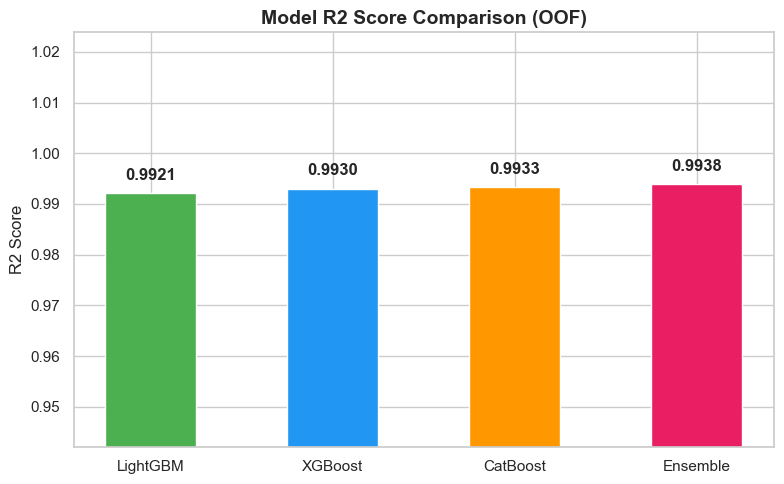

In [12]:
lgb_overall_r2 = r2_score(y, lgb_oof)
xgb_overall_r2 = r2_score(y, xgb_oof)
cat_overall_r2 = r2_score(y, cat_oof)

# Model R2 comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble']
r2_scores_list = [lgb_overall_r2, xgb_overall_r2, cat_overall_r2, final_r2]
colors_bar = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63']
bars = ax.bar(models, r2_scores_list, color=colors_bar, edgecolor='white', width=0.5)
for bar, score in zip(bars, r2_scores_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Model R2 Score Comparison (OOF)', fontsize=14, fontweight='bold')
ax.set_ylabel('R2 Score')
ax.set_ylim(min(r2_scores_list) - 0.05, max(r2_scores_list) + 0.03)
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '10_model_comparison.png'), dpi=150); plt.show()

# Prediction distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y, bins=60, alpha=0.5, label='Actual (Train)', color='#2196F3', density=True)
ax.hist(final_preds, bins=60, alpha=0.5, label='Predicted (Test)', color='#FF5722', density=True)
ax.set_title('Actual vs Predicted Demand Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Demand'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '11_actual_vs_predicted_dist.png'), dpi=150); plt.show()

# Fold-wise R2
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(N_FOLDS); width = 0.25
ax.bar(x_pos - width, lgb_scores, width, label='LightGBM', color='#4CAF50', alpha=0.85)
ax.bar(x_pos, xgb_scores, width, label='XGBoost', color='#2196F3', alpha=0.85)
ax.bar(x_pos + width, cat_scores, width, label='CatBoost', color='#FF9800', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_title('Fold-wise R2 Scores', fontsize=14, fontweight='bold')
ax.set_ylabel('R2 Score'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '12_foldwise_r2.png'), dpi=150); plt.show()

## 13. Generate Submission

In [ ]:
final_preds = np.clip(final_preds, 0, 1)

submission = pd.DataFrame({'Index': test_index, 'demand': final_preds})
submission.to_csv('submission.csv', index=False)

print(f"Submission shape: {submission.shape}")
print(f"Demand range: [{submission['demand'].min():.6f}, {submission['demand'].max():.6f}]")
print(f"Demand mean: {submission['demand'].mean():.6f}")

assert submission.shape == (41778, 2), f"Expected (41778, 2), got {submission.shape}"
assert list(submission.columns) == ['Index', 'demand']
print("[OK] Submission format verified!")
display(submission.head(10))